# Predicting Road Accident Severity in Great Britain Using Environmental and Road Conditions

## Preparation

- [Github link](https://github.com/SeymaBerker/CASA0006-road-safety)

- Number of words: 1500

- Runtime: 0.25 hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) 

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
      
    * `xgboost 3.2.0` 
    * `shap` 
    * `imbalanced-learn` 

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Road traffic collisions are a major public health issue globally (WHO, 2023) and in Great Britain. Severe injuries continue to occur unevenly across space, time, and road environments, and understanding why some collisions result in fatal or serious injury matters for designing targeted interventions in enforcement, lighting, road design, and speed management.

This project uses the STATS19 2024 collision dataset (Department for Transport, 2024) to examine accident severity across Great Britain. The main aim is to identify whether severe collisions are associated with particular environmental and temporal conditions and whether these relationships can be used to predict whether a collision is fatal or serious. The analysis combines exploratory spatial analysis, unsupervised clustering, supervised machine learning, and model interpretation in a connected three-stage pipeline in which each stage informs the next. Previous research has shown that environmental conditions such as lighting and road surface significantly affect injury outcomes (Abdulhafedh, 2017) and that factors influencing crash severity exhibit temporal and contextual instability across different road environments (Behnood and Mannering, 2019).

## Research questions

[[ go back to the top ]](#Table-of-contents)

**RQ1:** How does road accident severity vary across space and time in Great Britain in 2024?

**RQ2:** What environmental and road condition profiles are associated with higher accident severity?

**RQ3:** Can accident severity be predicted using environmental, spatial, and temporal features, and which variables are most important?

## Data

[[ go back to the top ]](#Table-of-contents)

This study uses the STATS19 2024 collision dataset (Department for Transport, 2024), recording all personal injury road collisions reported to the police in Great Britain. The release comprises 100,927 collision records across 44 variables in coded integer format; values of -1 indicate missing records and are treated as missing prior to analysis.

The target variable `collision_severity` (coded 1=Fatal, 2=Serious, 3=Slight) is collapsed to binary: fatal and serious collisions are coded 1, slight collisions 0. After cleaning, 93,279 rows remain, of which 25.6% are fatal or serious. A majority classifier predicting every collision as slight would achieve 74.4% accuracy while failing to identify any severe case, the accuracy paradox, so F1-score and ROC-AUC are used as primary metrics throughout. Temporal features including month, hour, rush hour flag, weekend flag, and season are extracted from the `date` and `time` columns.

| Variable | Type | Source | Role | Notes |
|---|---|---|---|---|
| `collision_severity` | Categorical (1/2/3) | STATS19 | Dependent variable source | Collapsed to binary |
| `severity_binary` | Binary | Derived | Dependent variable | Fatal/serious=1, slight=0 |
| `speed_limit` | Numeric | STATS19 | Predictor | mph |
| `road_type` | Categorical | STATS19 | Predictor | Encoded integer |
| `light_conditions` | Categorical | STATS19 | Predictor | Daylight vs darkness variants |
| `weather_conditions` | Categorical | STATS19 | Predictor | Fine, rain, snow etc. |
| `road_surface_conditions` | Categorical | STATS19 | Predictor | Dry, wet, ice etc. |
| `junction_detail` | Categorical | STATS19 | Predictor | Junction type |
| `urban_or_rural_area` | Categorical (1/2) | STATS19 | Predictor | Urban vs rural |
| `number_of_vehicles` | Numeric | STATS19 | Predictor | Count involved |
| `day_of_week` | Categorical | STATS19 | Predictor | 1=Sunday to 7=Saturday |
| `month` | Numeric | Derived | Temporal predictor | Extracted from date |
| `hour` | Numeric | Derived | Temporal predictor | Extracted from time |
| `is_rush_hour` | Binary | Derived | Temporal predictor | 7-9am and 5-7pm |
| `is_weekend` | Binary | Derived | Temporal predictor | Saturday/Sunday |
| `season` | Categorical | Derived | Temporal predictor | 1=Spring to 4=Winter |
| `cluster_label` | Categorical | Derived | Engineered predictor | From k-means Stage 2 |
| `latitude` / `longitude` | Numeric | STATS19 | Spatial mapping only | Not used in model |

**Cleaning decisions:** The dataset uses -1 for missing or out-of-range values, replaced with NaN and rows dropped. Rows with unallocated urban/rural code (3) and unknown speed limit code (99) are removed to ensure all variables used in modelling have interpretable values.

In [1]:
# Install additional libraries not included in the base environment
!pip install xgboost shap imbalanced-learn --break-system-packages -q
print("Installation complete")

Installation complete


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import contextily as ctx
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.dummy import DummyClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported successfully
XGBoost version: 3.2.0


In [3]:
# Load STATS19 2024 collision data
df_raw = pd.read_csv(
    "https://raw.githubusercontent.com/SeymaBerker/CASA0006-road-safety/main/dft-road-casualty-statistics-collision-2024.csv",
    low_memory=False
)
print("Raw dataset shape:", df_raw.shape)
print("\nTarget variable distribution:")
print(df_raw["collision_severity"].value_counts().sort_index())

Raw dataset shape: (100927, 44)

Target variable distribution:
collision_severity
1     1502
2    23567
3    75858
Name: count, dtype: int64


In [4]:
# Select columns needed for analysis
KEEP_COLS = [
    "collision_severity", "speed_limit", "road_type",
    "light_conditions", "weather_conditions", "road_surface_conditions",
    "junction_detail", "urban_or_rural_area", "number_of_vehicles",
    "day_of_week", "date", "time", "latitude", "longitude"
]

df = df_raw[KEEP_COLS].copy()

# Replace STATS19 missing/out of range code (-1) with NaN and drop affected rows
df.replace(-1, np.nan, inplace=True)
df.dropna(inplace=True)

# Remove the unallocated urban/rural rows (code 3)
df = df[df["urban_or_rural_area"].isin([1, 2])]

# Remove unknown speed limits (99 = unknown self-reported)
df = df[df["speed_limit"] != 99]

# Binary target: Fatal (1) and Serious (2) = 1, Slight (3) = 0
df["severity_binary"] = df["collision_severity"].isin([1, 2]).astype(int)

print("Shape after cleaning:", df.shape)
print("\nBinary severity distribution:")
print(df["severity_binary"].value_counts())
print("\nClass balance:")
print(df["severity_binary"].value_counts(normalize=True).round(3))
print(f"\nMajority classifier accuracy: {1 - df['severity_binary'].mean():.1%}")
print("F1 and AUC are used as primary metrics to avoid the accuracy paradox")

Shape after cleaning: (93279, 15)

Binary severity distribution:
severity_binary
0    69431
1    23848
Name: count, dtype: int64

Class balance:
severity_binary
0    0.744
1    0.256
Name: proportion, dtype: float64

Majority classifier accuracy: 74.4%
F1 and AUC are used as primary metrics to avoid the accuracy paradox


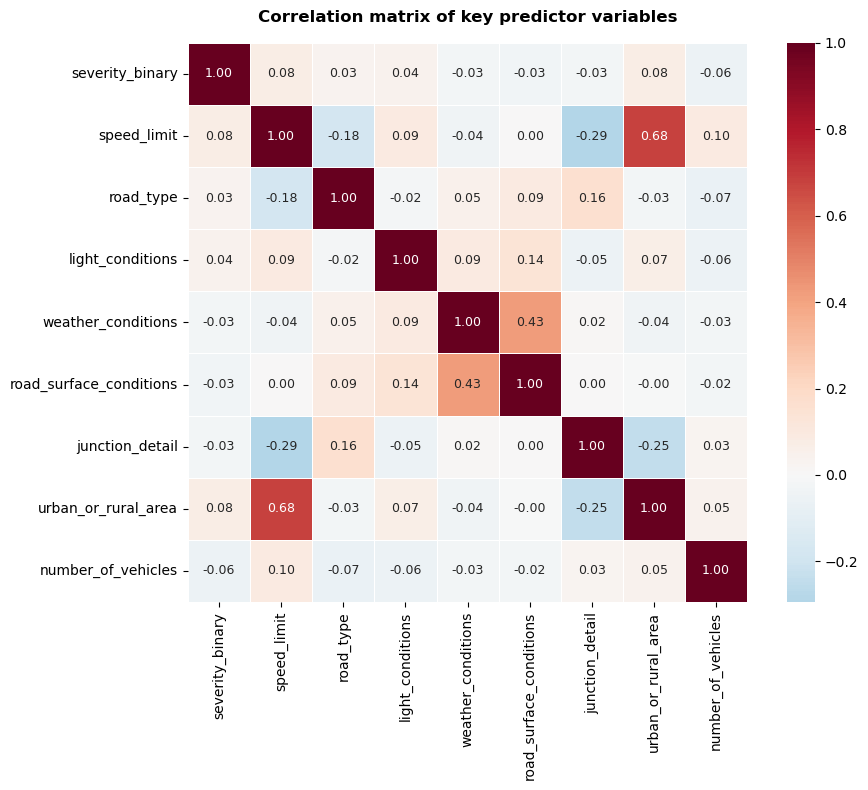

Correlation matrix displayed.


In [5]:
# Correlation matrix of key numerical features
import seaborn as sns

corr_features = [
    'severity_binary', 'speed_limit', 'road_type', 'light_conditions',
    'weather_conditions', 'road_surface_conditions', 'junction_detail',
    'urban_or_rural_area', 'number_of_vehicles'
]

corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation matrix of key predictor variables',
             fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('Correlation matrix displayed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation matrix displayed.")

The correlation matrix shows no single variable has a strong linear correlation with severity_binary. Speed limit has the highest positive correlation (r = 0.08) and number_of_vehicles the highest negative (r = -0.06). The strongest inter-feature correlation is between speed_limit and urban_or_rural_area (r = 0.68), explaining elevated VIF values for these variables. Weather_conditions and road_surface_conditions correlate moderately (r = 0.43), reflecting that adverse weather produces worse road surfaces. These weak individual correlations motivate the clustering approach in Stage 2.

In [6]:
# Extract temporal features from date and time columns
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')
df['time'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce')
df['hour'] = df['time'].dt.hour
df.dropna(subset=['hour'], inplace=True)
df['hour'] = df['hour'].astype(int)
df['month'] = df['date'].dt.month

# Rush hour flag: 7-9am and 5-7pm
df['is_rush_hour'] = (
    df['hour'].isin(range(7, 10)) | df['hour'].isin(range(17, 20))
).astype(int)

# Weekend flag: Sunday=1, Saturday=7 in STATS19 coding
df['is_weekend'] = df['day_of_week'].isin([1, 7]).astype(int)

# Season derived from month
season_map = {12:4, 1:4, 2:4,
              3:1,  4:1, 5:1,
              6:2,  7:2, 8:2,
              9:3,  10:3, 11:3}
df['season'] = df['month'].map(season_map)

print(f"Shape after temporal extraction: {df.shape}")
print(f"\nSample of temporal features:")
print(df[['month','hour','is_rush_hour','is_weekend','season']].head())
print(f"\nRush hour accidents: {df['is_rush_hour'].sum():,} ({df['is_rush_hour'].mean():.1%})")
print(f"Weekend accidents:   {df['is_weekend'].sum():,} ({df['is_weekend'].mean():.1%})")

Shape after temporal extraction: (93279, 20)

Sample of temporal features:
   month  hour  is_rush_hour  is_weekend  season
0     12    16             0           0       4
1     10    14             0           0       3
2      1    17             1           0       4
3      5    17             1           0       1
4      8    15             0           1       2

Rush hour accidents: 33,744 (36.2%)
Weekend accidents:   23,305 (25.0%)


## Methodology

[[go back to the top]](#Table-of-contents)

This project uses a three-stage analytical pipeline in which each stage builds on the previous, following the principle that methods should serve the research question. All modelling follows a strict train-test split protocol in which the held-out test set is never used during training or hyperparameter tuning.

**Stage 1: Exploratory spatial and temporal analysis**

The first stage describes the dataset and identifies key patterns in severity across speed limits, lighting conditions, urban/rural classification, road surface, hour of day, month, and geography. Accident locations are mapped using GeoPandas and contextily with a CartoDB basemap to visualise the spatial distribution of severe collisions across Great Britain. This stage directly addresses RQ1.

**Stage 2: K-means clustering of environmental conditions**

The second stage groups collisions into environmental profiles using speed limit, road type, light conditions, weather conditions, and road surface conditions. All variables are standardised using StandardScaler before fitting, as k-means is distance-based and sensitive to feature scale. The number of clusters is selected using the elbow method and silhouette score. The resulting cluster labels are added as an engineered feature for Stage 3, connecting the unsupervised and supervised stages. K-means is applied before the train-test split; because it uses no target variable, this does not introduce leakage into the supervised stage.

**Stage 3: XGBoost classification and SHAP interpretation**

The third stage trains an XGBoost classifier to predict binary severity. SMOTE is applied inside the training pipeline via imblearn.Pipeline, preventing data leakage into the test set (Chawla et al., 2002). GridSearchCV with 5-fold stratified cross-validation tunes hyperparameters using F1-score. A majority classifier baseline is included for comparison. SHAP values are computed post-hoc using shap.TreeExplainer to interpret which variables drive predictions and in which direction.

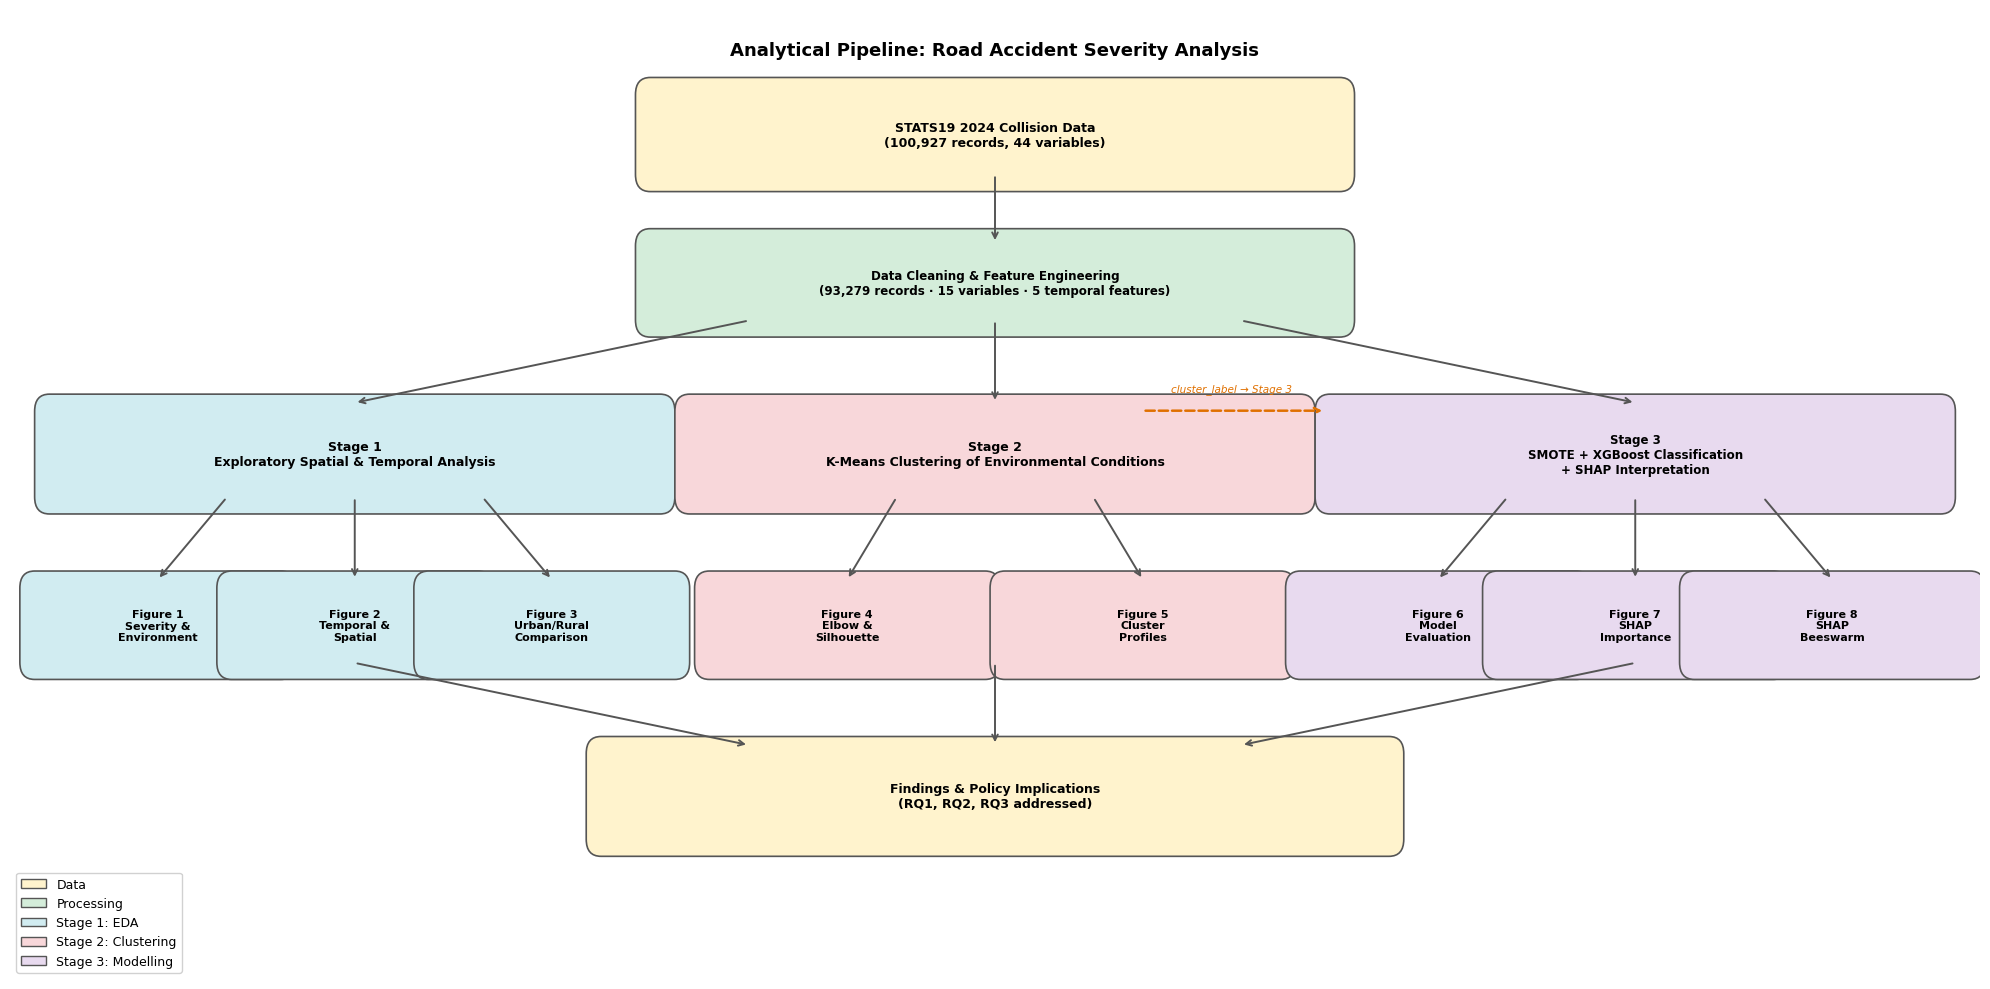

Methodology flowchart saved.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(20, 10))
ax.set_xlim(0, 20)
ax.set_ylim(3.5, 12)
ax.axis('off')

def box(ax, x, y, w, h, text, color, fontsize=8.5):
    b = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle="round,pad=0.15",
                       facecolor=color, edgecolor='#555555', linewidth=1.2)
    ax.add_patch(b)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', multialignment='center')

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.4))

# Title
ax.text(10, 11.6, 'Analytical Pipeline: Road Accident Severity Analysis',
        ha='center', fontsize=13, fontweight='bold')

# Row 1: Data
box(ax, 10, 10.9, 7, 0.7,
    'STATS19 2024 Collision Data\n(100,927 records, 44 variables)',
    '#FFF3CD', fontsize=9)
arrow(ax, 10, 10.55, 10, 9.95)

# Row 2: Cleaning
box(ax, 10, 9.6, 7, 0.65,
    'Data Cleaning & Feature Engineering\n(93,279 records · 15 variables · 5 temporal features)',
    '#D4EDDA', fontsize=8.5)

# Three arrows fanning out
arrow(ax, 7.5, 9.27, 3.5, 8.55)
arrow(ax, 10,  9.27, 10,  8.55)
arrow(ax, 12.5,9.27, 16.5,8.55)

# Row 3: Three stage boxes
box(ax, 3.5, 8.1, 6.2, 0.75,
    'Stage 1\nExploratory Spatial & Temporal Analysis',
    '#D1ECF1', fontsize=9)

box(ax, 10, 8.1, 6.2, 0.75,
    'Stage 2\nK-Means Clustering of Environmental Conditions',
    '#F8D7DA', fontsize=9)

box(ax, 16.5, 8.1, 6.2, 0.75,
    'Stage 3\nSMOTE + XGBoost Classification\n+ SHAP Interpretation',
    '#E8DAEF', fontsize=8.5)

# Dashed arrow Stage 2 → Stage 3 
ax.annotate('', xy=(13.35, 8.48), xytext=(11.5, 8.48),
            arrowprops=dict(arrowstyle='->', color='#E07000',
                            lw=1.8, linestyle='dashed'))
ax.text(12.4, 8.65, 'cluster_label → Stage 3',
        ha='center', fontsize=7.5, color='#E07000', style='italic')

# Stage 1 outputs — 3 figures
arrow(ax, 2.2, 7.72, 1.5, 7.0)
arrow(ax, 3.5, 7.72, 3.5, 7.0)
arrow(ax, 4.8, 7.72, 5.5, 7.0)

box(ax, 1.5, 6.6, 2.5, 0.65,
    'Figure 1\nSeverity &\nEnvironment', '#D1ECF1', fontsize=8)
box(ax, 3.5, 6.6, 2.5, 0.65,
    'Figure 2\nTemporal &\nSpatial', '#D1ECF1', fontsize=8)
box(ax, 5.5, 6.6, 2.5, 0.65,
    'Figure 3\nUrban/Rural\nComparison', '#D1ECF1', fontsize=8)

# Stage 2 outputs — 2 figures
arrow(ax, 9.0, 7.72, 8.5, 7.0)
arrow(ax, 11.0,7.72, 11.5,7.0)

box(ax, 8.5, 6.6, 2.8, 0.65,
    'Figure 4\nElbow &\nSilhouette', '#F8D7DA', fontsize=8)
box(ax, 11.5,6.6, 2.8, 0.65,
    'Figure 5\nCluster\nProfiles', '#F8D7DA', fontsize=8)

# Stage 3 outputs — 3 figures
arrow(ax, 15.2,7.72, 14.5,7.0)
arrow(ax, 16.5,7.72, 16.5,7.0)
arrow(ax, 17.8,7.72, 18.5,7.0)

box(ax, 14.5,6.6, 2.8, 0.65,
    'Figure 6\nModel\nEvaluation', '#E8DAEF', fontsize=8)
box(ax, 16.5,6.6, 2.8, 0.65,
    'Figure 7\nSHAP\nImportance', '#E8DAEF', fontsize=8)
box(ax, 18.5,6.6, 2.8, 0.65,
    'Figure 8\nSHAP\nBeeswarm', '#E8DAEF', fontsize=8)

# Converge to findings
arrow(ax, 3.5,  6.27, 7.5,  5.55)
arrow(ax, 10,   6.27, 10,   5.55)
arrow(ax, 16.5, 6.27, 12.5, 5.55)

box(ax, 10, 5.1, 8, 0.75,
    'Findings & Policy Implications\n(RQ1, RQ2, RQ3 addressed)',
    '#FFF3CD', fontsize=9)

# Legend
legend_items = [
    mpatches.Patch(facecolor='#FFF3CD', edgecolor='#555', label='Data'),
    mpatches.Patch(facecolor='#D4EDDA', edgecolor='#555', label='Processing'),
    mpatches.Patch(facecolor='#D1ECF1', edgecolor='#555', label='Stage 1: EDA'),
    mpatches.Patch(facecolor='#F8D7DA', edgecolor='#555', label='Stage 2: Clustering'),
    mpatches.Patch(facecolor='#E8DAEF', edgecolor='#555', label='Stage 3: Modelling'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=9,
          framealpha=0.9, bbox_to_anchor=(0.0, 0.0))

plt.tight_layout()
plt.savefig('fig0_methodology_flowchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Methodology flowchart saved.")

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

### Stage 1: Exploratory Spatial and Temporal Analysis

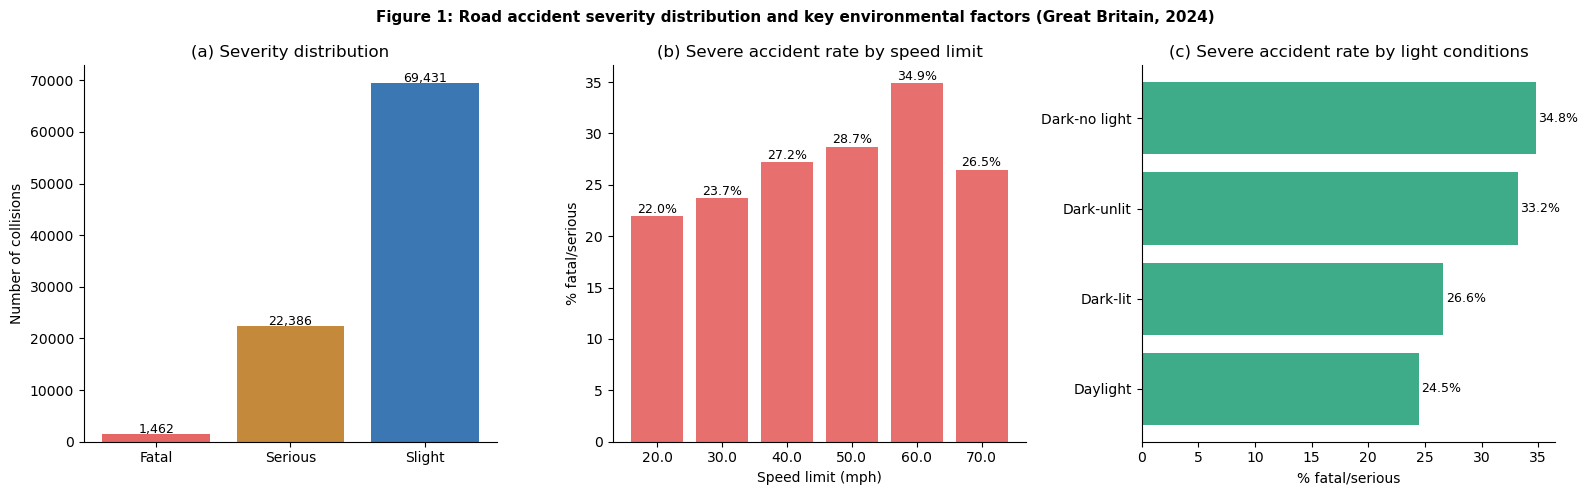

Figure 1 saved.


In [8]:
# Colour scheme used throughout
COL_FATAL   = "#E24B4A"
COL_SERIOUS = "#BA7517"
COL_SLIGHT  = "#185FA5"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Figure 1: Road accident severity distribution and key environmental factors (Great Britain, 2024)",
    fontweight="bold", fontsize=11)

# Severity distribution
sev_counts = df["collision_severity"].value_counts().sort_index()
sev_labels = {1: "Fatal", 2: "Serious", 3: "Slight"}
axes[0].bar([sev_labels[i] for i in sev_counts.index], sev_counts.values,
            color=[COL_FATAL, COL_SERIOUS, COL_SLIGHT], alpha=0.85)
axes[0].set_title("(a) Severity distribution")
axes[0].set_ylabel("Number of collisions")
axes[0].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(sev_counts.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontsize=9)

# Severe accident rate by speed limit
speed_sev = df.groupby("speed_limit")["severity_binary"].mean() * 100
speed_sev = speed_sev[speed_sev.index.isin([20, 30, 40, 50, 60, 70])]
axes[1].bar(speed_sev.index.astype(str), speed_sev.values,
            color=COL_FATAL, alpha=0.8)
axes[1].set_title("(b) Severe accident rate by speed limit")
axes[1].set_xlabel("Speed limit (mph)")
axes[1].set_ylabel("% fatal/serious")
axes[1].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(speed_sev.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

# Severe rate by light conditions
light_map = {1: "Daylight", 4: "Dark-lit", 5: "Dark-unlit", 6: "Dark-no light"}
light_sev = (df[df["light_conditions"].isin(light_map.keys())]
             .groupby("light_conditions")["severity_binary"].mean() * 100)
light_sev.index = [light_map[i] for i in light_sev.index]
axes[2].barh(light_sev.index, light_sev.values, color="#1D9E75", alpha=0.85)
axes[2].set_title("(c) Severe accident rate by light conditions")
axes[2].set_xlabel("% fatal/serious")
axes[2].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(light_sev.values):
    axes[2].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig1_severity_environment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

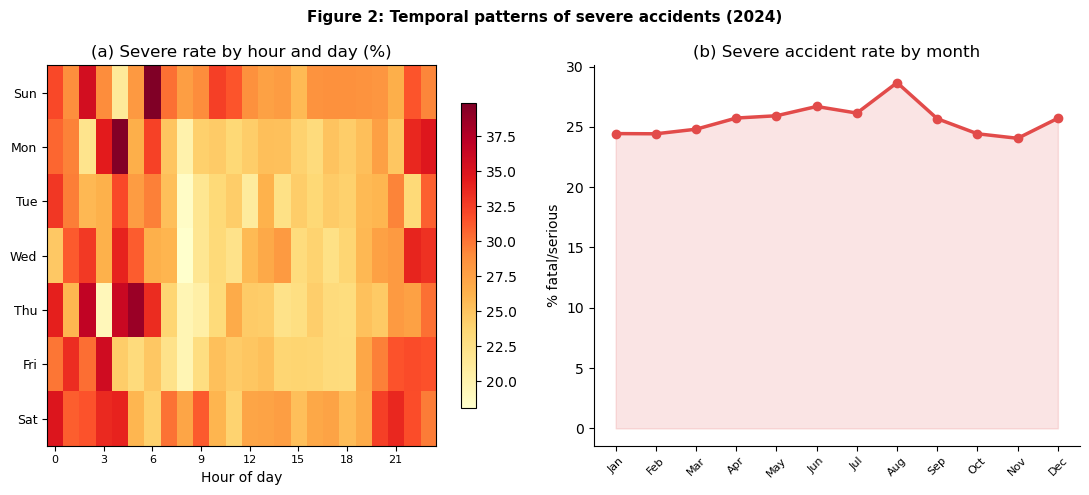

Figure 2 saved.


In [9]:
# Figure 2: Temporal patterns of severe accidents
fig = plt.figure(figsize=(11, 5))
fig.suptitle(
    "Figure 2: Temporal patterns of severe accidents (2024)",
    fontweight="bold", fontsize=11)

# Heatmap: severe rate by hour and day of week
ax1 = fig.add_subplot(121)
day_labels = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
heatmap_data = df.groupby(["day_of_week", "hour"])["severity_binary"].mean() * 100
heatmap_pivot = heatmap_data.unstack(level="hour")
heatmap_pivot.index = [day_labels[i] for i in heatmap_pivot.index]
im = ax1.imshow(heatmap_pivot.values, aspect="auto", cmap="YlOrRd")
ax1.set_xticks(range(0, 24, 3))
ax1.set_xticklabels(range(0, 24, 3), fontsize=8)
ax1.set_yticks(range(7))
ax1.set_yticklabels(heatmap_pivot.index, fontsize=9)
ax1.set_xlabel("Hour of day")
ax1.set_title("(a) Severe rate by hour and day (%)")
plt.colorbar(im, ax=ax1, shrink=0.8)

# Monthly severe rate
ax2 = fig.add_subplot(122)
month_sev = df.groupby("month")["severity_binary"].mean() * 100
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
ax2.plot(range(1,13), month_sev.values,
         color=COL_FATAL, linewidth=2.5, marker="o", markersize=6)
ax2.fill_between(range(1,13), month_sev.values, alpha=0.15, color=COL_FATAL)
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(month_labels, rotation=45, fontsize=8)
ax2.set_title("(b) Severe accident rate by month")
ax2.set_ylabel("% fatal/serious")
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig2_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

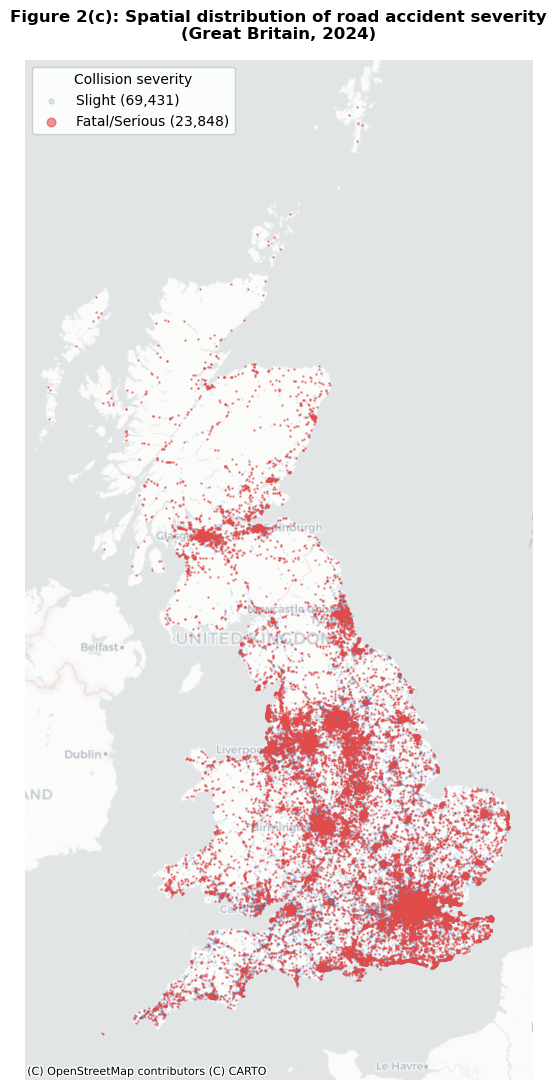

Figure 2c saved.


In [10]:
# Figure 2(c): Spatial distribution of fatal/serious accidents (Great Britain, 2024)
import geopandas as gpd

# Convert to GeoDataFrame with WGS84 coordinates then reproject for basemap
gdf = gpd.GeoDataFrame(
    df[["severity_binary", "latitude", "longitude"]],
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
).to_crs("EPSG:3857")

slight_mask = df["severity_binary"] == 0
severe_mask = df["severity_binary"] == 1

fig, ax = plt.subplots(figsize=(9, 11))

# Plot slight first so severe sits on top
gdf[slight_mask].plot(ax=ax, color=COL_SLIGHT, markersize=0.2,
                      alpha=0.15, label=f"Slight ({slight_mask.sum():,})")
gdf[severe_mask].plot(ax=ax, color=COL_FATAL, markersize=0.6,
                      alpha=0.6, label=f"Fatal/Serious ({severe_mask.sum():,})")

# Clean basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.7)

ax.set_title("Figure 2(c): Spatial distribution of road accident severity\n(Great Britain, 2024)",
             fontweight="bold", fontsize=12, pad=15)
ax.set_axis_off()

# Legend
ax.legend(fontsize=10, markerscale=8, title="Collision severity",
          title_fontsize=10, loc="upper left",
          framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()
plt.savefig("fig2c_spatial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2c saved.")

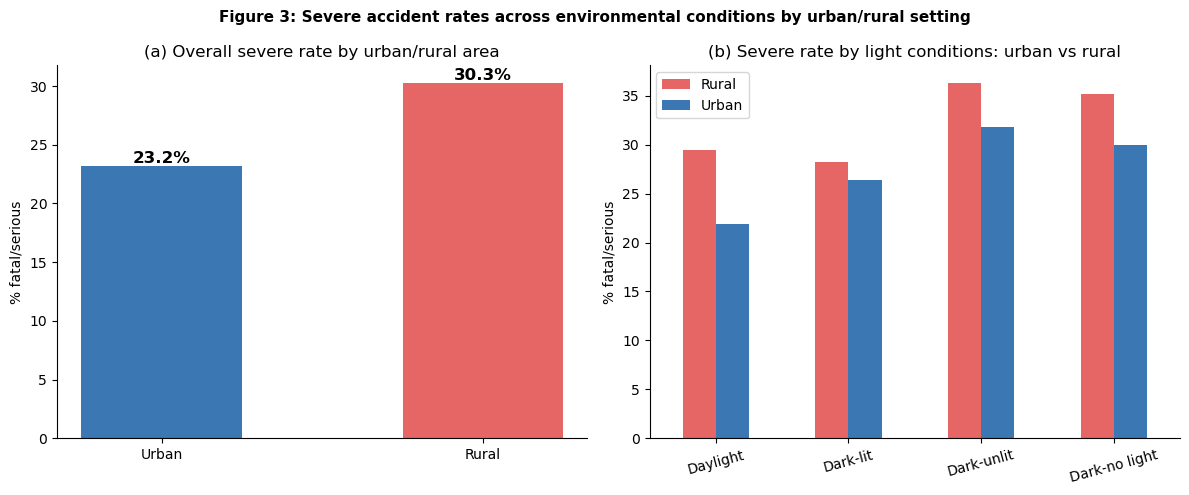

Figure 3 saved.


In [11]:
# Figure 3: Urban/rural severity and light conditions by urban/rural setting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Figure 3: Severe accident rates across environmental conditions by urban/rural setting",
    fontweight="bold", fontsize=11)

# Overall urban vs rural severe rate
ur_sev = df.groupby("urban_or_rural_area")["severity_binary"].mean() * 100
axes[0].bar(["Urban", "Rural"], ur_sev.values,
            color=[COL_SLIGHT, COL_FATAL], alpha=0.85, width=0.5)
axes[0].set_title("(a) Overall severe rate by urban/rural area")
axes[0].set_ylabel("% fatal/serious")
axes[0].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(ur_sev.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center",
                 fontweight="bold", fontsize=12)

# Light conditions by urban/rural grouped bar
light_df = df[df["light_conditions"].isin(light_map.keys())].copy()
light_df["light_label"] = light_df["light_conditions"].map(light_map)
light_df["urban_label"] = light_df["urban_or_rural_area"].map({1: "Urban", 2: "Rural"})
light_urban = (light_df.groupby(["light_label", "urban_label"])["severity_binary"]
               .mean().mul(100).unstack()
               .reindex(["Daylight", "Dark-lit", "Dark-unlit", "Dark-no light"]))
light_urban.plot(kind="bar", ax=axes[1],
                 color=[COL_FATAL, COL_SLIGHT], alpha=0.85)
axes[1].set_title("(b) Severe rate by light conditions: urban vs rural")
axes[1].set_ylabel("% fatal/serious")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig3_environment_urban_rural.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

**Stage 1 findings:**

Figure 1 confirms class imbalance: 69,431 slight collisions versus 22,386 serious and 1,462 fatal, motivating F1-score and ROC-AUC as primary metrics. Severe rates increase from 22.0% at 20mph to 34.9% at 60mph; the 70mph rate (26.5%) is lower, likely reflecting the controlled design of motorways compared with rural single carriageways at 60mph with greater roadside hazard exposure. Lighting shows a strong association: the daylight severe rate is 24.5%, rising to 34.8% on unlit roads, suggesting lighting investment could reduce severe accident rates.

Figure 2 shows severe rates peak between midnight and 6am. Rush hours show lower severe rates despite higher collision volumes, likely because lower speeds and greater driver alertness reduce injury severity. August shows the highest monthly severe rate with elevated winter values also apparent. Figure 2(c) shows the spatial distribution of accidents across Great Britain, with fatal and serious collisions visibly more dispersed across rural areas while slight collisions concentrate in urban centres such as London, Birmingham and Manchester.

Figure 3 shows rural roads consistently have higher severe rates than urban across all lighting conditions (30.3% vs 23.2% overall). The difference is most pronounced in daylight settings (rural 29.5% vs urban 21.8%). These findings motivate Stage 2 clustering by demonstrating that severity reflects combinations of conditions rather than single variables in isolation.

### Stage 2: K-means clustering of environmental conditions

Computing clustering diagnostics...
  k=2: inertia=368600, silhouette=0.536
  k=3: inertia=288905, silhouette=0.405
  k=4: inertia=227642, silhouette=0.431
  k=5: inertia=176542, silhouette=0.448
  k=6: inertia=137497, silhouette=0.496
  k=7: inertia=115218, silhouette=0.517
  k=8: inertia=101594, silhouette=0.538


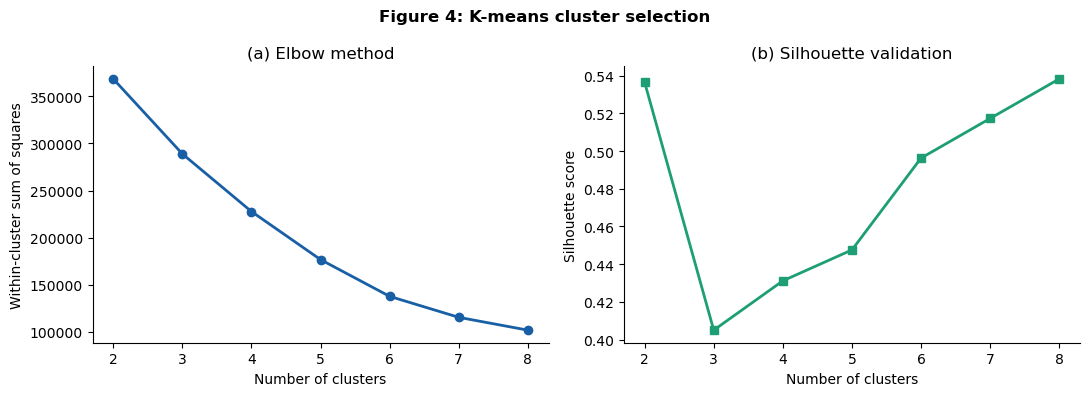

Figure 4 saved.


In [12]:
# K-means clustering of environmental conditions
CLUSTER_FEATURES = [
    "speed_limit", "road_type", "light_conditions",
    "weather_conditions", "road_surface_conditions"
]

df_cluster = df[CLUSTER_FEATURES].copy()

# Standardise features before fitting k-means
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df_cluster)

# Use a sample for silhouette score to reduce memory usage
from sklearn.utils import resample
sample_idx = resample(range(len(X_cluster_scaled)), 
                      n_samples=10000, random_state=42)
X_sample = X_cluster_scaled[sample_idx]

inertia    = []
silhouette = []
k_range    = range(2, 9)

print("Computing clustering diagnostics...")
for k in k_range:
    model  = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_cluster_scaled)
    inertia.append(model.inertia_)
    # Silhouette on sample only to save memory
    sample_labels = labels[sample_idx]
    silhouette.append(silhouette_score(X_sample, sample_labels))
    print(f"  k={k}: inertia={model.inertia_:.0f}, silhouette={silhouette[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Figure 4: K-means cluster selection", fontweight="bold")

axes[0].plot(list(k_range), inertia, "o-", color=COL_SLIGHT, linewidth=2)
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Within-cluster sum of squares")
axes[0].set_title("(a) Elbow method")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(list(k_range), silhouette, "s-", color="#1D9E75", linewidth=2)
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("(b) Silhouette validation")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig4_cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

In [13]:
# Fit k=4 cluster model
# k=4 selected: elbow shows a clear bend at k=4 giving interpretable profiles
# Silhouette peaks at k=2 but this is too coarse for policy-relevant profiling
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df["cluster_label"] = kmeans_final.fit_predict(X_cluster_scaled)

cluster_profile = df.groupby("cluster_label").agg(
    n_collisions=("collision_severity", "count"),
    pct_severe  =("severity_binary", "mean"),
    mean_speed  =("speed_limit", "mean"),
    mean_light  =("light_conditions", "mean"),
).round(3)
cluster_profile["pct_of_total"] = (
    cluster_profile["n_collisions"] / len(df) * 100).round(1)

print("Cluster profiles:")
print(cluster_profile)

Cluster profiles:
               n_collisions  pct_severe  mean_speed  mean_light  pct_of_total
cluster_label                                                                
0                     49955       0.258      34.569       1.000          53.6
1                     17916       0.220      42.880       2.063          19.2
2                      6234       0.207      32.870       2.414           6.7
3                     19174       0.298      34.546       4.634          20.6


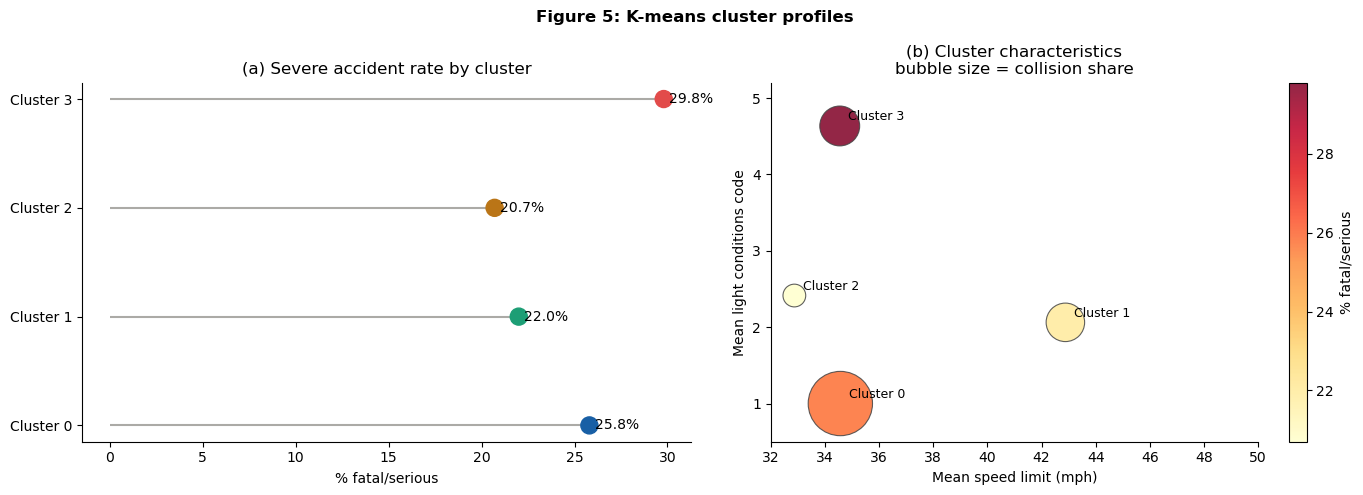

Figure 5 saved.


In [14]:
# Figure 5: K-means cluster profiles
CLUSTER_COLORS = ["#185FA5", "#1D9E75", "#BA7517", "#E24B4A"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 5: K-means cluster profiles", fontweight="bold", fontsize=12)

# Dot plot: severe accident rate by cluster
y_pos = np.arange(OPTIMAL_K)
axes[0].hlines(y=y_pos, xmin=0,
               xmax=cluster_profile["pct_severe"] * 100,
               color="#888780", linewidth=1.5, alpha=0.7)
axes[0].scatter(cluster_profile["pct_severe"] * 100, y_pos,
                color=CLUSTER_COLORS, s=150, zorder=3)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f"Cluster {i}" for i in range(OPTIMAL_K)])
axes[0].set_xlabel("% fatal/serious")
axes[0].set_title("(a) Severe accident rate by cluster")
axes[0].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(cluster_profile["pct_severe"] * 100):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)

# Bubble chart: speed vs light conditions
x_pos = cluster_profile["mean_speed"]
y_pos2 = cluster_profile["mean_light"]
sizes  = cluster_profile["pct_of_total"] * 40
scatter = axes[1].scatter(x_pos, y_pos2, s=sizes,
                          c=cluster_profile["pct_severe"] * 100,
                          cmap="YlOrRd", alpha=0.85,
                          edgecolors="#444444", linewidths=0.8)
plt.colorbar(scatter, ax=axes[1], label="% fatal/serious")
for i in range(OPTIMAL_K):
    axes[1].annotate(f"Cluster {i}",
                     (x_pos.iloc[i], y_pos2.iloc[i]),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].set_xlabel("Mean speed limit (mph)")
axes[1].set_ylabel("Mean light conditions code")
axes[1].set_title("(b) Cluster characteristics\nbubble size = collision share")
axes[1].set_xlim(32, 50)
axes[1].set_ylim(0.5, 5.2)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig5_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 5 saved.")

**Stage 2 findings:**

The elbow plot shows steady inertia reduction as k increases, while the silhouette score peaks at k=2 then rises again at larger values. k=4 is selected as a practical compromise, giving interpretable environmental profiles without over-fragmenting the data. Silhouette scores were computed on a 10,000-observation sample for computational efficiency.

Figure 5 shows four meaningful cluster differences. Cluster 0 (53.6%, severe rate 25.8%, mean speed 34.6mph) represents the most common daylight environment. Cluster 1 (19.2%, severe rate 22.0%, mean speed 42.9mph) has the highest speed but lower severity, though causality cannot be established from this cross-sectional analysis. Cluster 2 (6.7%) has the lowest severe rate at 20.7%. Cluster 3 (20.6%, severe rate 29.8%, mean light code 4.63) represents the highest-risk dark-road environment and its label is retained as an engineered feature for Stage 3.

*Critical reflection:* K-means assumes spherical clusters and treats encoded categorical variables as numeric distances. A k-medoids approach using Gower distance would be more theoretically appropriate for future work.

### Stage 3: XGBoost severity classification

In [15]:
# Feature set for classification
FEATURE_COLS = [
    "speed_limit", "road_type", "light_conditions", "weather_conditions",
    "road_surface_conditions", "junction_detail", "urban_or_rural_area",
    "number_of_vehicles", "day_of_week", "month", "hour",
    "is_rush_hour", "is_weekend", "season", "cluster_label"
]

X = df[FEATURE_COLS].copy()
y = df["severity_binary"].copy()

print("Feature matrix:", X.shape)
print("\nClass balance:")
print(y.value_counts(normalize=True).round(3))

# VIF computed for transparency — all features retained
# High VIF reflects encoded categorical integer structure of STATS19 data
# not true multicollinearity among conceptually distinct road-safety variables
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values.astype(float), i)
    for i in range(X.shape[1])
]
vif_data = vif_data.sort_values("VIF", ascending=False)
print("\nVIF results (reported for transparency):")
print(vif_data.to_string(index=False))
print("\nAll features retained.")
print("High VIF reflects encoded categorical structure, not conceptual multicollinearity.")

FEATURE_COLS_CLEAN = FEATURE_COLS.copy()
X = df[FEATURE_COLS_CLEAN].copy()

Feature matrix: (93279, 15)

Class balance:
severity_binary
0    0.744
1    0.256
Name: proportion, dtype: float64

VIF results (reported for transparency):
                feature       VIF
    urban_or_rural_area 16.836543
            speed_limit 13.846640
              road_type 11.048416
       light_conditions  7.588388
                   hour  7.502358
     number_of_vehicles  6.917546
                 season  6.428998
          cluster_label  5.242442
            day_of_week  5.129474
                  month  4.762828
road_surface_conditions  3.717781
     weather_conditions  2.443829
        junction_detail  2.166817
           is_rush_hour  1.576882
             is_weekend  1.353072

All features retained.
High VIF reflects encoded categorical structure, not conceptual multicollinearity.


In [16]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Pipeline: StandardScaler -> SMOTE -> XGBoost
# imblearn.Pipeline ensures SMOTE applies only to training data
pipeline = ImbPipeline([
    ("scaler",     StandardScaler()),
    ("smote",      SMOTE(random_state=42)),
    ("classifier", xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42, n_jobs=-1))
])

print("\nPipeline steps:")
for name, step in pipeline.steps:
    print(f"  {name}: {type(step).__name__}")

# Hyperparameter grid
param_grid = {
    "classifier__max_depth":      [3, 5, 7],
    "classifier__min_split_loss": [0, 1, 5],
    "classifier__subsample":      [0.5, 0.7, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV uses F1 not accuracy
grid_search = GridSearchCV(
    estimator=pipeline, param_grid=param_grid,
    scoring="f1", cv=cv, n_jobs=-1, verbose=1, return_train_score=True)

print("\nRunning GridSearchCV...")
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", round(grid_search.best_score_, 4))

Training set: (74623, 15)
Test set: (18656, 15)

Pipeline steps:
  scaler: StandardScaler
  smote: SMOTE
  classifier: XGBClassifier

Running GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': 7, 'classifier__min_split_loss': 0, 'classifier__subsample': 0.5}
Best CV F1-score: 0.1415


In [17]:
# Final evaluation on held-out test set
best_model  = grid_search.best_estimator_
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

# Majority classifier baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_dummy      = dummy.predict(X_test)
y_dummy_prob = dummy.predict_proba(X_test)[:, 1]
f1_dummy     = f1_score(y_test, y_dummy)
auc_dummy    = roc_auc_score(y_test, y_dummy_prob)

# Comparison table
comparison_df = pd.DataFrame({
    "Model":    ["XGBoost", "Majority baseline"],
    "F1-score": [round(f1, 3), round(f1_dummy, 3)],
    "ROC-AUC":  [round(auc, 3), round(auc_dummy, 3)],
})
print("Model performance comparison")
print(comparison_df.to_string(index=False))
print("\nAccuracy not reported — majority classifier achieves 74.4% by ignoring severe class")

print("\nClassification report:")
print(classification_report(y_test, y_pred,
      target_names=["Slight", "Fatal/Serious"]))

print("\nPerformance by urban/rural classification:")
for value, label in [(1, "Urban"), (2, "Rural")]:
    mask = X_test["urban_or_rural_area"] == value
    print(f"  {label}: F1={f1_score(y_test[mask], y_pred[mask]):.3f}  "
          f"AUC={roc_auc_score(y_test[mask], y_pred_prob[mask]):.3f}  "
          f"n={mask.sum():,}")

Model performance comparison
            Model  F1-score  ROC-AUC
          XGBoost     0.144    0.589
Majority baseline     0.000    0.500

Accuracy not reported — majority classifier achieves 74.4% by ignoring severe class

Classification report:
               precision    recall  f1-score   support

       Slight       0.75      0.95      0.84     13886
Fatal/Serious       0.39      0.09      0.14      4770

     accuracy                           0.73     18656
    macro avg       0.57      0.52      0.49     18656
 weighted avg       0.66      0.73      0.66     18656


Performance by urban/rural classification:
  Urban: F1=0.092  AUC=0.576  n=12,468
  Rural: F1=0.212  AUC=0.583  n=6,188


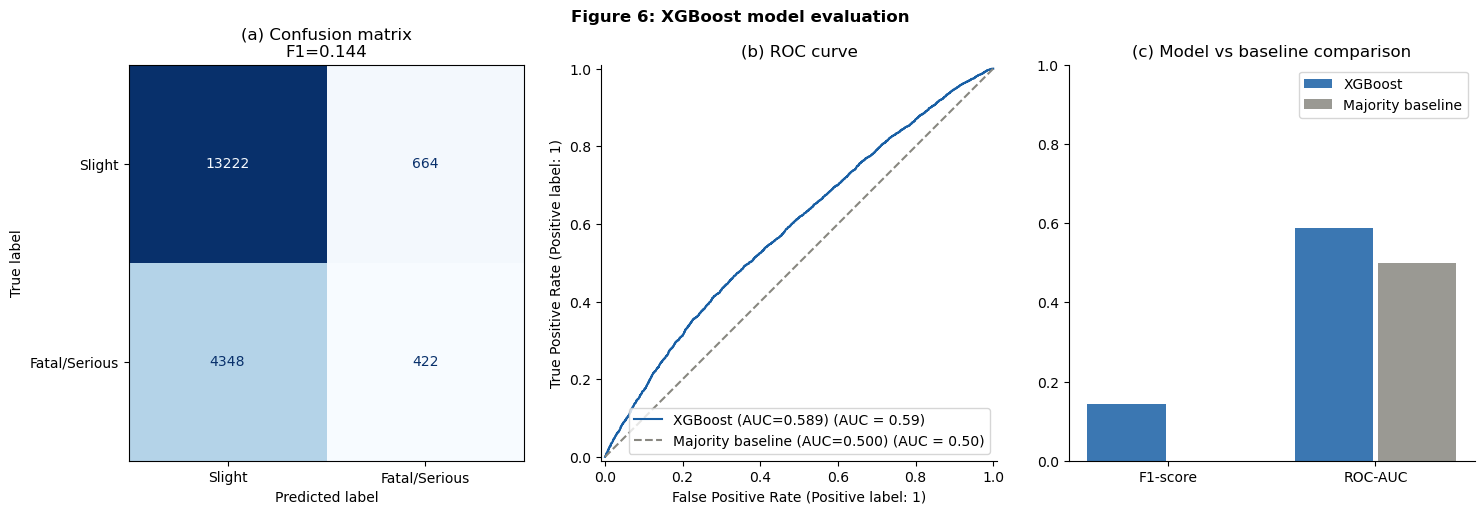

Figure 6 saved.


In [18]:
# Figure 6: Model evaluation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 6: XGBoost model evaluation", fontweight="bold", fontsize=12)

# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Slight", "Fatal/Serious"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"(a) Confusion matrix\nF1={f1:.3f}")

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_pred_prob,
    name=f"XGBoost (AUC={auc:.3f})", ax=axes[1], color=COL_SLIGHT)
RocCurveDisplay.from_predictions(
    y_test, y_dummy_prob,
    name=f"Majority baseline (AUC={auc_dummy:.3f})",
    ax=axes[1], color="#888780", linestyle="--")
axes[1].set_title("(b) ROC curve")
axes[1].spines[["top", "right"]].set_visible(False)

# Bar comparison
metrics    = ["F1-score", "ROC-AUC"]
xgb_vals   = [f1, auc]
dummy_vals = [f1_dummy, auc_dummy]
x = np.arange(len(metrics))
axes[2].bar(x - 0.2, xgb_vals,   0.38, label="XGBoost",
            color=COL_SLIGHT, alpha=0.85)
axes[2].bar(x + 0.2, dummy_vals, 0.38, label="Majority baseline",
            color="#888780", alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0, 1)
axes[2].set_title("(c) Model vs baseline comparison")
axes[2].legend()
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig6_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 6 saved.")

In [19]:
# SHAP feature importance
xgb_model    = best_model.named_steps["classifier"]
scaler_model = best_model.named_steps["scaler"]

X_test_scaled    = scaler_model.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS_CLEAN)

print("Computing SHAP values...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled_df)

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({
    "feature":       FEATURE_COLS_CLEAN,
    "mean_abs_shap": mean_shap
}).sort_values("mean_abs_shap", ascending=False)

print("SHAP global feature importance:")
print(shap_df.to_string(index=False))

fi_df = pd.DataFrame({
    "feature":        FEATURE_COLS_CLEAN,
    "xgb_importance": xgb_model.feature_importances_
}).sort_values("xgb_importance", ascending=False)
print("\nBuilt-in XGBoost feature importance:")
print(fi_df.to_string(index=False))

Computing SHAP values...
SHAP global feature importance:
                feature  mean_abs_shap
                   hour       0.257595
     number_of_vehicles       0.241819
            speed_limit       0.196734
                  month       0.188749
              road_type       0.141190
            day_of_week       0.134482
           is_rush_hour       0.130093
        junction_detail       0.107233
                 season       0.089302
     weather_conditions       0.062196
road_surface_conditions       0.062189
       light_conditions       0.055704
          cluster_label       0.047457
    urban_or_rural_area       0.042038
             is_weekend       0.038178

Built-in XGBoost feature importance:
                feature  xgb_importance
            speed_limit        0.128343
        junction_detail        0.107797
                  month        0.103088
                   hour        0.095019
     weather_conditions        0.087368
            day_of_week        0.073931
 

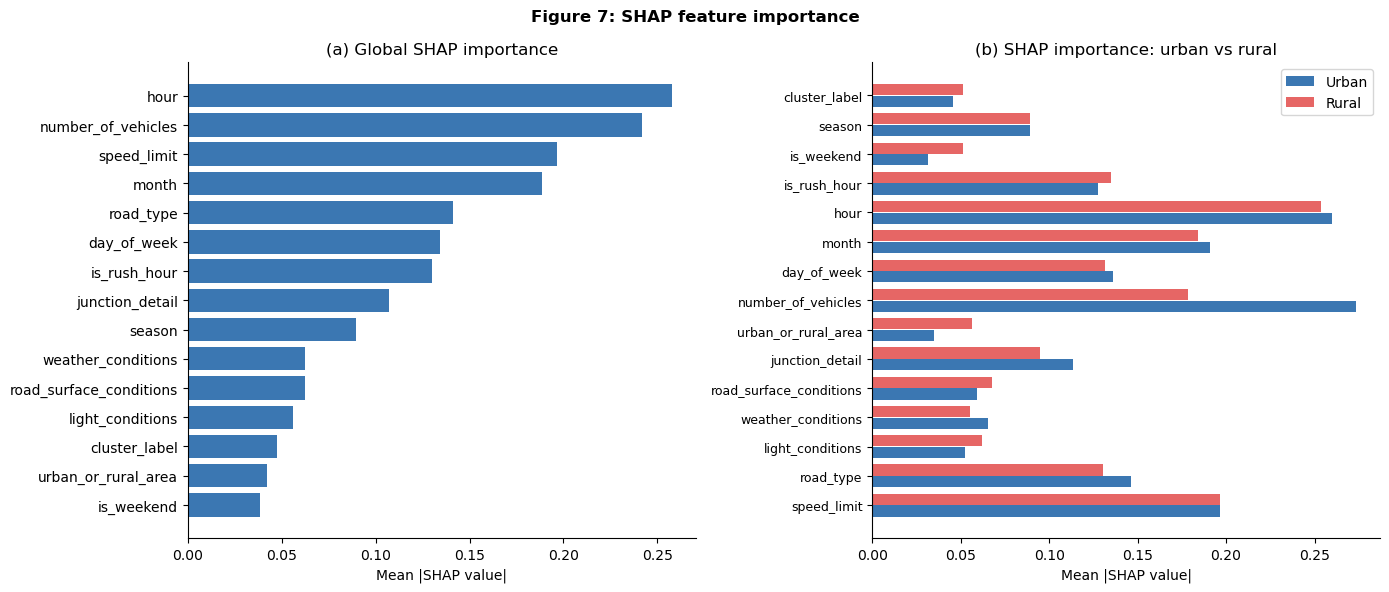

Figure 7 saved.


In [20]:
# Figure 7: SHAP importance plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 7: SHAP feature importance", fontweight="bold", fontsize=12)

# Global SHAP bar chart
order = np.argsort(mean_shap)
axes[0].barh([FEATURE_COLS_CLEAN[i] for i in order],
             mean_shap[order], color=COL_SLIGHT, alpha=0.85)
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("(a) Global SHAP importance")
axes[0].spines[["top", "right"]].set_visible(False)

# Urban vs rural SHAP comparison
urban_mask = (X_test["urban_or_rural_area"] == 1).values
rural_mask = (X_test["urban_or_rural_area"] == 2).values
shap_urban = np.abs(shap_values[urban_mask]).mean(axis=0)
shap_rural = np.abs(shap_values[rural_mask]).mean(axis=0)
y_pos = np.arange(len(FEATURE_COLS_CLEAN))
axes[1].barh(y_pos - 0.2, shap_urban, 0.38,
             color=COL_SLIGHT, alpha=0.85, label="Urban")
axes[1].barh(y_pos + 0.2, shap_rural, 0.38,
             color=COL_FATAL, alpha=0.85, label="Rural")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(FEATURE_COLS_CLEAN, fontsize=9)
axes[1].set_xlabel("Mean |SHAP value|")
axes[1].set_title("(b) SHAP importance: urban vs rural")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig7_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 7 saved.")

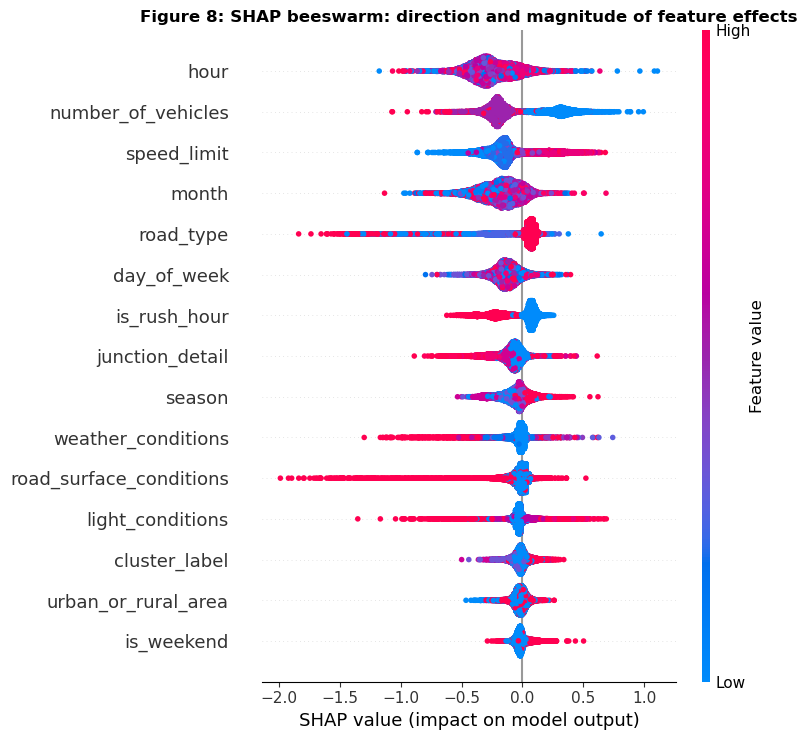

Figure 8 saved.


In [21]:
# Figure 8: SHAP beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.title("Figure 8: SHAP beeswarm: direction and magnitude of feature effects",
          fontweight="bold")
plt.tight_layout()
plt.savefig("fig8_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 8 saved.")

**Stage 3 findings:**

The XGBoost classifier achieves F1=0.144 and AUC=0.589, outperforming the majority baseline (F1=0.000, AUC=0.500). The model identifies slight collisions well (recall 0.95) but detects only 1 in 10 severe collisions (recall 0.09). This reflects the absence of key variables such as vehicle speed, driver behaviour, and traffic volume (Abdulhafedh, 2017). Best hyperparameters were max_depth=7, min_split_loss=0, subsample=0.5.

SHAP analysis identifies hour (0.258), number of vehicles (0.242), speed limit (0.197), month (0.189), and road type (0.141) as the strongest predictors. The dominance of temporal features confirms the value of engineering hour and month as predictors. The beeswarm plot shows high speed limits push predictions towards severe outcomes, while rush hour conditions reduce predicted severity. The cluster label contributes SHAP=0.047, confirming the Stage 2 analytical link adds predictive signal. Rural areas show higher predictive performance (F1=0.212, AUC=0.583) than urban (F1=0.092, AUC=0.576).

*Critical reflection:* Binary collapse loses granularity between fatal and serious outcomes. STATS19 underreporting of minor collisions may bias the training distribution, and cross-sectional data precludes causal inference.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This project analysed road accident severity in Great Britain using the STATS19 2024 collision dataset, combining exploratory spatial analysis, k-means clustering, XGBoost classification, and SHAP interpretation in a connected three-stage pipeline.

For RQ1, severe accidents vary clearly across space and time. Higher severity is associated with higher speed limits, dark lighting, rural roads, and late-night hours. Rural roads show a higher severe rate (30.3%) than urban roads (23.2%).

For RQ2, k-means clustering identified four environmental profiles with different severity rates. The highest-risk profile (Cluster 3, severe rate 29.8%) was associated with dark road environments, confirming that severity reflects combinations of conditions rather than single variables.

For RQ3, the XGBoost model achieved F1=0.144 and AUC=0.589, outperforming the majority baseline. SHAP identified hour, number of vehicles, speed limit, month, and road type as the strongest predictors. The cluster label (SHAP=0.047) validated the analytical link between Stages 2 and 3. Low recall (0.09) shows severity is difficult to predict from environmental variables alone.

Interventions should prioritise rural roads, high-speed roads, and dark environments through speed management, improved lighting, and late-night enforcement.

Limitations include low predictive performance, binary severity target, and cross-sectional data preventing causal inference. Future work should integrate traffic volume data and explore geographically weighted models.

## References

[[ go back to the top ]](#Table-of-contents)

Abdulhafedh, A. (2017). ‘Road Crash Prediction Models: Different Statistical Modeling Approaches’. Journal of Transportation Technologies, 07(02), pp. 190–205. Available at: https://doi.org/10.4236/jtts.2017.72014.

Behnood, A. and Mannering, F. (2019). ‘Time-of-day variations and temporal instability of factors affecting injury severities in large-truck crashes’. Analytic Methods in Accident Research, 23, p. 100102. Available at: https://doi.org/10.1016/j.amar.2019.100102.

Chawla, N. V., Bowyer, K. W., Hall, L. O. and Kegelmeyer, W. P. (2002). ‘SMOTE: Synthetic Minority Over-sampling Technique’. Journal of Artificial Intelligence Research, 16, pp. 321–357. Available at: https://doi.org/10.1613/jair.953.

Department for Transport. (2024). Road safety open data. GOV.UK. Available at: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data (Accessed: 20 April 2026).

World Health Organization. (2023). Road traffic injuries. World Health Organization. Available at: https://www.who.int/news-room/fact-sheets/detail/road-traffic-injuries (Accessed: 20 April 2026).